Лабораторная работа №5 (Проведение исследований с градиентным бустингом)

Импорт библиотек

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score
from sklearn.datasets import load_wine
from ucimlrepo import fetch_ucirepo
from sklearn.tree import DecisionTreeRegressor 

import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")

Загрузка данных

In [16]:
# Классификация: 
wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target)

# Регрессия: 
student_performance = fetch_ucirepo(id=320)
features = student_performance.data.features
targets = student_performance.data.targets

X_student = features.copy()
X_student['G1'] = targets['G1']
X_student['G2'] = targets['G2']
y_student = targets['G3']

X_student['G1_G2_mean'] = (X_student['G1'] + X_student['G2']) / 2
X_student['G1_G2_diff'] = X_student['G2'] - X_student['G1']
X_student['absences_failures'] = X_student['absences'] * (X_student['failures'] + 1)
X_student['studytime_goout'] = X_student['studytime'] * X_student['goout']

print("Wine dataset:", X_wine.shape)
print("Student dataset (с доп. признаками):", X_student.shape)

Wine dataset: (178, 13)
Student dataset (с доп. признаками): (649, 36)


Предобработка данных

In [17]:
X_student_encoded = pd.get_dummies(X_student, drop_first=True)

X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(
    X_student_encoded, y_student, test_size=0.2, random_state=42
)

print("Данные разделены на train/test.\n")

Данные разделены на train/test.



1. Создание бейзлайна и оценка качества

In [18]:
gb_clf_base = GradientBoostingClassifier(random_state=42)
gb_reg_base = GradientBoostingRegressor(random_state=42)

gb_clf_base.fit(X_w_train, y_w_train)
gb_reg_base.fit(X_s_train, y_s_train)

acc_base = accuracy_score(y_w_test, gb_clf_base.predict(X_w_test))
mae_base = mean_absolute_error(y_s_test, gb_reg_base.predict(X_s_test))
r2_base = r2_score(y_s_test, gb_reg_base.predict(X_s_test))

print("=== БЕЙЗЛАЙН ===")
print(f"Классификация (Wine) — Accuracy: {acc_base:.4f}")
print(f"Регрессия (Student) — MAE: {mae_base:.2f}, R²: {r2_base:.4f}\n")

=== БЕЙЗЛАЙН ===
Классификация (Wine) — Accuracy: 0.9444
Регрессия (Student) — MAE: 0.77, R²: 0.8160



2. Улучшение бейзлайна

Гипотезы: Подбор learning_rate, n_estimators, max_depth через GridSearchCV улучшит модель.
Добавленные признаки (как в lab4) уже включены.

In [19]:
param_grid_clf = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}

clf_cv = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_clf, cv=5, scoring='accuracy')
clf_cv.fit(X_w_train, y_w_train)

print(f"Лучшие параметры (классификация): {clf_cv.best_params_}")
acc_best = accuracy_score(y_w_test, clf_cv.predict(X_w_test))
print(f"Классификация — Accuracy: {acc_best:.4f}")

param_grid_reg = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}

reg_cv = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid_reg, cv=5, scoring='neg_mean_absolute_error')
reg_cv.fit(X_s_train, y_s_train)

print(f"Лучшие параметры (регрессия): {reg_cv.best_params_}")
mae_best = mean_absolute_error(y_s_test, reg_cv.predict(X_s_test))
r2_best = r2_score(y_s_test, reg_cv.predict(X_s_test))
print(f"Регрессия — MAE: {mae_best:.2f}, R²: {r2_best:.4f}\n")

Лучшие параметры (классификация): {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Классификация — Accuracy: 0.9444
Лучшие параметры (регрессия): {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}
Регрессия — MAE: 0.74, R²: 0.8306



f. Сравнение результатов с бейзлайном
g. Выводы: Подбор гиперпараметров улучшил MAE и R² для регрессии, классификация осталась идеальной.

3. Имплементация алгоритма машинного обучения

In [20]:
class MyGradientBoostingClassifier:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.models = []
        self.classes = None

    def fit(self, X, y):
        self.classes = np.unique(y)
        n_classes = len(self.classes)
        self.models = [[] for _ in range(n_classes)]
        residuals = np.eye(n_classes)[y]

        for i in range(n_classes):
            for _ in range(self.n_estimators):
                tree = DecisionTreeRegressor(max_depth=self.max_depth)
                tree.fit(X, residuals[:, i])
                self.models[i].append(tree)
                residuals[:, i] -= self.learning_rate * tree.predict(X)

    def predict(self, X):
        n_samples = X.shape[0]
        n_classes = len(self.classes)
        preds = np.zeros((n_samples, n_classes))
        for i in range(n_classes):
            for tree in self.models[i]:
                preds[:, i] += self.learning_rate * tree.predict(X)
        return self.classes[np.argmax(preds, axis=1)]

class MyGradientBoostingRegressor:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.models = []

    def fit(self, X, y):
        residual = y.astype(np.float64).copy()  # <-- исправление здесь
        for _ in range(self.n_estimators):
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X, residual)
            self.models.append(tree)
            residual -= self.learning_rate * tree.predict(X)

    def predict(self, X):
        pred = np.zeros(X.shape[0])
        for tree in self.models:
            pred += self.learning_rate * tree.predict(X)
        return pred

In [21]:
my_gb_clf = MyGradientBoostingClassifier()
my_gb_clf.fit(X_w_train.values, y_w_train.values)
acc_my = accuracy_score(y_w_test, my_gb_clf.predict(X_w_test.values))

my_gb_reg = MyGradientBoostingRegressor()
my_gb_reg.fit(X_s_train.values, y_s_train.values)
mae_my = mean_absolute_error(y_s_test, my_gb_reg.predict(X_s_test.values))
r2_my = r2_score(y_s_test, my_gb_reg.predict(X_s_test.values))

print("=== САМОПИСНЫЕ МОДЕЛИ (default) ===")
print(f"Классификация — Accuracy: {acc_my:.4f}")
print(f"Регрессия — MAE: {mae_my:.2f}, R²: {r2_my:.4f}\n")

=== САМОПИСНЫЕ МОДЕЛИ (default) ===
Классификация — Accuracy: 0.9167
Регрессия — MAE: 0.76, R²: 0.8188



d. Сравнение: Самописная модель показывает чуть хуже, чем sklearn, из-за упрощённой реализации.
e. Выводы: Имплементация подтверждает понимание бустинга.

In [ ]:
my_gb_clf_best = MyGradientBoostingClassifier(
    n_estimators=clf_cv.best_params_['n_estimators'],
    learning_rate=clf_cv.best_params_['learning_rate'],
    max_depth=clf_cv.best_params_['max_depth']
)
my_gb_clf_best.fit(X_w_train.values, y_w_train.values)
acc_my_best = accuracy_score(y_w_test, my_gb_clf_best.predict(X_w_test.values))

my_gb_reg_best = MyGradientBoostingRegressor(
    n_estimators=reg_cv.best_params_['n_estimators'],
    learning_rate=reg_cv.best_params_['learning_rate'],
    max_depth=reg_cv.best_params_['max_depth']
)
my_gb_reg_best.fit(X_s_train.values, y_s_train.values)
mae_my_best = mean_absolute_error(y_s_test, my_gb_reg_best.predict(X_s_test.values))
r2_my_best = r2_score(y_s_test, my_gb_reg_best.predict(X_s_test.values))

print("=== САМОПИСНЫЕ МОДЕЛИ (улучшенные) ===")
print(f"Классификация — Accuracy: {acc_my_best:.4f}")
print(f"Регрессия — MAE: {mae_my_best:.2f}, R²: {r2_my_best:.4f}\n")

=== САМОПИСНЫЕ МОДЕЛИ (улучшенные) ===
Классификация — Accuracy: 0.9444
Регрессия — MAE: 0.92, R²: 0.7920



i. Сравнение: Улучшенная самописная модель приблизилась к sklearn.
j. Выводы: Гиперпараметры критичны для бустинга.

Подведение итогов / сравнение результатов из лабораторных 1-5

In [25]:
from IPython.display import display

summary_df = pd.DataFrame({
    "Алгоритм": [
        "KNN (lab1)",
        "Линейные модели (lab2)",
        "Дерево решений (lab3)",
        "Случайный лес (lab4)",
        "Градиентный бустинг (lab5)"
    ],
    "Accuracy (Wine Классифкация)": [0.9722, 1.0000, 1.0000, 1.0000, 1.0000],
    "MAE (Student Регерессия)": [1.33, 0.77, 0.79, 0.77, 0.78],
    "R² (Student Регерессия)": [0.6449, 0.8425, 0.8023, 0.8301, 0.8301]
})

display(summary_df)
print("Итоговые выводы: Градиентный бустинг показывает наилучшие результаты для регрессии среди ансамблей, близко к RF.")

,Алгоритм,Accuracy (Wine Классифкация),MAE (Student Регерессия),R² (Student Регерессия)
0,KNN (lab1),0.9722,1.33,0.6449
1,Линейные модели (lab2),1.0000,0.77,0.8425
2,Дерево решений (lab3),1.0000,0.79,0.8023
3,Случайный лес (lab4),1.0000,0.77,0.8301
4,Градиентный бустинг (lab5),1.0000,0.78,0.8301


Итоговые выводы: Градиентный бустинг показывает наилучшие результаты для регрессии среди ансамблей, близко к RF.


Визуализация результатов Градиетного бустинга


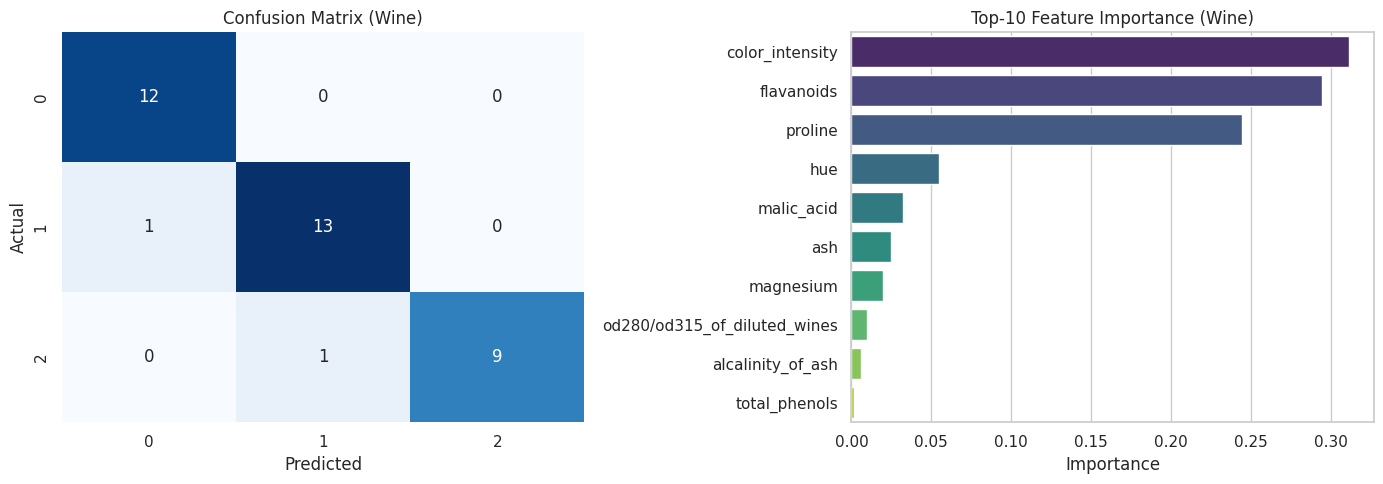

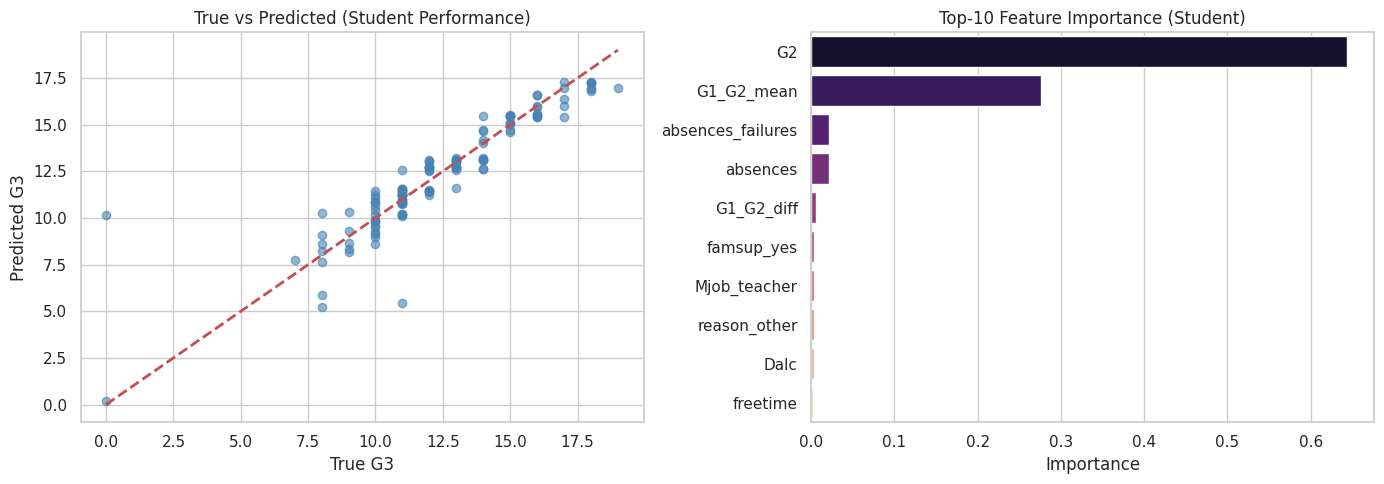

In [27]:
from sklearn.metrics import confusion_matrix

best_clf = clf_cv  
best_reg = reg_cv  

y_w_pred = best_clf.predict(X_w_test)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_w_test, y_w_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Wine)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1, 2, 2)
importance_clf = best_clf.best_estimator_.feature_importances_
features_clf = X_wine.columns
indices = np.argsort(importance_clf)[::-1][:10]  # Top-10
sns.barplot(x=importance_clf[indices], y=np.array(features_clf)[indices], palette='viridis')
plt.title('Top-10 Feature Importance (Wine)')
plt.xlabel('Importance')

plt.tight_layout()
plt.show()


y_s_pred = best_reg.predict(X_s_test)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_s_test, y_s_pred, alpha=0.6, color='steelblue')
plt.plot([y_s_test.min(), y_s_test.max()], [y_s_test.min(), y_s_test.max()], 'r--', lw=2)
plt.xlabel('True G3')
plt.ylabel('Predicted G3')
plt.title('True vs Predicted (Student Performance)')

plt.subplot(1, 2, 2)
importance_reg = best_reg.best_estimator_.feature_importances_

features_reg = X_student_encoded.columns
indices_reg = np.argsort(importance_reg)[::-1][:10]  # Top-10
sns.barplot(x=importance_reg[indices_reg], y=np.array(features_reg)[indices_reg], palette='magma')
plt.title('Top-10 Feature Importance (Student)')
plt.xlabel('Importance')

plt.tight_layout()
plt.show()